# 05 - Entrenamiento del Modelo Cognitivo Artificial

**Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad**

- **Autor:** Jesús Goenaga Peña
- **Programa:** Doctorado en Ciencias Cognitivas - Universidad Autónoma de Manizales

---

Entrenamiento en dos etapas según la sección 8.4.1.3 de la tesis:

| Etapa | Fases congeladas | Learning Rate | Objetivo |
|-------|-----------------|---------------|----------|
| 1 | NGL + V1 (7-15) | 0.001 | Optimizar capas superiores y salida |
| 2 | Ninguna | 0.0001 | Fine-tuning global del modelo completo |

## 1. Configuración

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

PROJECT_ROOT = '/content/drive/MyDrive/cognitive-depth-model'
REPO_DIR = '/content/cognitive-depth-model'

if os.path.exists(REPO_DIR):
    !cd {REPO_DIR} && git pull
else:
    !git clone https://github.com/yisusgoenaga/cognitive-depth-model.git {REPO_DIR}

# Encontrar src automáticamente
result = subprocess.run(['find', REPO_DIR, '-name', 'cognitive_model.py'], capture_output=True, text=True)
model_path = result.stdout.strip()
src_dir = os.path.dirname(os.path.dirname(model_path))
sys.path.insert(0, src_dir)

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'Src: {src_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Dispositivo: cuda
Src: /content/cognitive-depth-model/cognitive-depth-model/src


## 2. Cargar Datos

In [ ]:
from training.dataset import KITTIStereoDepthDataset
from torch.utils.data import DataLoader

KITTI_RAW = os.path.join(PROJECT_ROOT, 'data/raw/kitti')
SPLITS_FILE = os.path.join(PROJECT_ROOT, 'data/splits/kitti_splits.json')

# Fix: los IDs ya traen "_10", hay que indicar la ruta correcta
# Las imágenes están en data_scene_flow/training/
import json

with open(SPLITS_FILE) as f:
    splits = json.load(f)

# Rutas directas
TRAIN_LEFT = os.path.join(KITTI_RAW, 'data_scene_flow/training/image_2')
TRAIN_RIGHT = os.path.join(KITTI_RAW, 'data_scene_flow/training/image_3')
TRAIN_DISP = os.path.join(KITTI_RAW, 'data_scene_flow/training/disp_occ_0')

# Dataset manual simplificado
class FixedKITTIDataset(torch.utils.data.Dataset):
    def __init__(self, scene_ids, left_dir, right_dir, disp_dir, target_size=(256, 512), augment=False):
        self.left_dir = left_dir
        self.right_dir = right_dir
        self.disp_dir = disp_dir
        self.target_size = target_size
        self.augment = augment

        # Filtrar IDs que existen
        self.scene_ids = []
        for sid in scene_ids:
            if os.path.exists(os.path.join(left_dir, f'{sid}.png')):
                self.scene_ids.append(sid)
        print(f'Dataset: {len(self.scene_ids)} escenas encontradas')

    def __len__(self):
        return len(self.scene_ids)

    def __getitem__(self, idx):
        import cv2, random, numpy as np
        sid = self.scene_ids[idx]
        h, w = self.target_size

        # Cargar imágenes
        img_l = cv2.imread(os.path.join(self.left_dir, f'{sid}.png'))
        img_r = cv2.imread(os.path.join(self.right_dir, f'{sid}.png'))
        img_l = cv2.resize(img_l, (w, h)).astype(np.float32) / 255.0
        img_r = cv2.resize(img_r, (w, h)).astype(np.float32) / 255.0

        # Cargar disparidad y generar etiqueta
        disp_path = os.path.join(self.disp_dir, f'{sid}.png')
        if os.path.exists(disp_path):
            disp = cv2.imread(disp_path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 256.0
            disp = cv2.resize(disp, (w, h))
            # Comparar mitad izquierda vs derecha
            left_half = disp[:, :w//2]
            right_half = disp[:, w//2:]
            valid_l = left_half[left_half > 0]
            valid_r = right_half[right_half > 0]
            if len(valid_l) > 0 and len(valid_r) > 0:
                label = 1.0 if valid_l.mean() > valid_r.mean() else 0.0
            else:
                label = 0.5
        else:
            label = 0.5

        # Augmentation (solo brillo/contraste)
        if self.augment:
            factor = random.uniform(0.9, 1.1)
            img_l = np.clip(img_l * factor, 0, 1)
            img_r = np.clip(img_r * factor, 0, 1)

        # Tensores
        left_t = torch.from_numpy(img_l).permute(2, 0, 1)
        right_t = torch.from_numpy(img_r).permute(2, 0, 1)
        stereo = torch.cat([left_t, right_t], dim=0)  # (6, H, W)
        label_t = torch.tensor([label], dtype=torch.float32)

        return stereo, label_t

# Crear datasets y loaders
train_dataset = FixedKITTIDataset(splits['kitti_train'], TRAIN_LEFT, TRAIN_RIGHT, TRAIN_DISP, target_size=(64, 128), augment=True)
test_dataset = FixedKITTIDataset(splits['kitti_test'], TRAIN_LEFT, TRAIN_RIGHT, TRAIN_DISP, target_size=(64, 128), augment=False)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nBatches de entrenamiento: {len(train_loader)}')
print(f'Batches de prueba: {len(test_loader)}')

Dataset: 140 escenas encontradas
Dataset: 60 escenas encontradas

Batches de entrenamiento: 70
Batches de prueba: 30


Batch de entrada:  torch.Size([2, 6, 64, 128])  (batch, 6ch, H, W)
Batch de labels:   torch.Size([2, 1])
Rango de entrada:  [0.004, 1.000]
Labels del batch:  [0.0, 0.0]


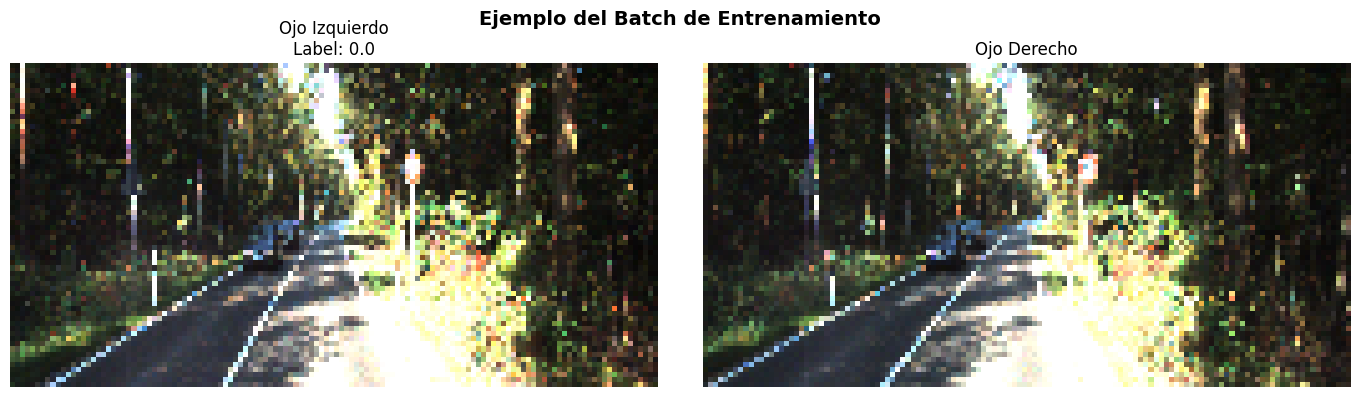

In [ ]:
# Verificar un batch
sample_batch, sample_labels = next(iter(train_loader))

print(f'Batch de entrada:  {sample_batch.shape}  (batch, 6ch, H, W)')
print(f'Batch de labels:   {sample_labels.shape}')
print(f'Rango de entrada:  [{sample_batch.min():.3f}, {sample_batch.max():.3f}]')
print(f'Labels del batch:  {sample_labels.squeeze().tolist()}')

# Visualizar un ejemplo del batch
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Ejemplo del Batch de Entrenamiento', fontsize=14, fontweight='bold')

# Ojo izquierdo (canales 0-2)
left = sample_batch[0, :3].permute(1, 2, 0).numpy()
axes[0].imshow(left[:, :, ::-1])  # BGR a RGB
axes[0].set_title(f'Ojo Izquierdo\nLabel: {sample_labels[0].item():.1f}')
axes[0].axis('off')

# Ojo derecho (canales 3-5)
right = sample_batch[0, 3:].permute(1, 2, 0).numpy()
axes[1].imshow(right[:, :, ::-1])
axes[1].set_title('Ojo Derecho')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Crear el Modelo

In [ ]:
from model.cognitive_model import CognitiveDepthModel

model = CognitiveDepthModel(
    in_channels=6,
    ngl_magno=8,
    ngl_parvo=8,
    v1_channels=16,
    v2_channels=32,
    v3_channels=64,
    v4_channels=64,
    v5_channels=128,
    integration_units=128,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Modelo ligero: {total_params:,} parámetros')

with torch.no_grad():
    test_out = model(torch.randn(2, 6, 64, 128).to(device))
    print(f'Forward pass OK: {test_out.shape}')

Modelo ligero: 2,800,209 parámetros
Forward pass OK: torch.Size([2, 1])


## 4. Entrenamiento

**Etapa 1:** Congelamos NGL y V1 (Fases 7-15). Solo entrenamos V2, V3, V4, V5/MT y la salida.
Esto permite que la capa de decisión aprenda primero sin alterar las representaciones tempranas.

**Etapa 2:** Descongelamos todo y hacemos fine-tuning con learning rate reducido.
Esto ajusta la coherencia global entre todas las fases.

In [ ]:
# Liberar memoria GPU
import gc
torch.cuda.empty_cache()
gc.collect()

51

In [ ]:
from training.trainer import train_model

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')

# Habilitar mixed precision para ahorrar memoria
torch.cuda.empty_cache()

print('Iniciando entrenamiento del Modelo Cognitivo Artificial')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print()

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    checkpoint_dir=CHECKPOINT_DIR,
    stage1_epochs=30,
    stage2_epochs=70,
    stage1_lr=0.001,
    stage2_lr=0.0001,
    patience=15,
)

Iniciando entrenamiento del Modelo Cognitivo Artificial
Checkpoints: /content/drive/MyDrive/cognitive-depth-model/checkpoints


ETAPA 1: Entrenamiento con fases 7-15 congeladas
Fases 7-15 congeladas. Parámetros entrenables: 2,751,153 / 2,800,209
E1 [  1/30] Loss: 0.7406/0.8773 Acc: 0.536/0.550 F1: 0.472 LR: 1.00e-03 (747.4s)
E1 [  2/30] Loss: 0.7047/0.6765 Acc: 0.471/0.600 F1: 0.315 LR: 1.00e-03 (13.6s)
E1 [  3/30] Loss: 0.7041/1.7814 Acc: 0.536/0.517 F1: 0.504 LR: 1.00e-03 (14.9s)
E1 [  4/30] Loss: 0.7034/0.7166 Acc: 0.571/0.517 F1: 0.508 LR: 1.00e-03 (13.3s)
E1 [  5/30] Loss: 0.7003/0.6749 Acc: 0.557/0.567 F1: 0.456 LR: 1.00e-03 (13.2s)
E1 [  6/30] Loss: 0.7205/0.6879 Acc: 0.493/0.567 F1: 0.441 LR: 1.00e-03 (15.0s)
E1 [  7/30] Loss: 0.7006/0.7320 Acc: 0.529/0.467 F1: 0.468 LR: 1.00e-03 (13.2s)
E1 [  8/30] Loss: 0.6901/0.7060 Acc: 0.557/0.517 F1: 0.523 LR: 1.00e-03 (13.2s)
E1 [  9/30] Loss: 0.7017/0.6923 Acc: 0.564/0.567 F1: 0.315 LR: 1.00e-03 (13.4s)
E1 [ 10/30] Loss: 0.6946/0.6947 A

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
# ============================================
# ETAPA 2: Fine-tuning manual (continuación)
# ============================================
from training.trainer import train_one_epoch, evaluate, unfreeze_all, EarlyStopping
import time

# Cargar mejor modelo de Etapa 1
checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, 'best_model.pth'),
    weights_only=False  # Fix para PyTorch 2.10+
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo de Etapa 1 cargado (época {checkpoint["epoch"]})')

# Descongelar todo
unfreeze_all(model)

# Configurar Etapa 2
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, min_lr=1e-7)
early_stop = EarlyStopping(patience=15)

print('\n' + '=' * 60)
print('ETAPA 2: Fine-tuning del modelo completo')
print('=' * 60)

history_stage2 = {'train': [], 'test': [], 'epoch': [], 'lr': []}
best_test_loss = checkpoint['test_loss']

for epoch in range(70):
    start = time.time()

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_metrics = evaluate(model, test_loader, criterion, device)

    lr = optimizer.param_groups[0]['lr']
    scheduler.step(test_metrics['loss'])
    elapsed = time.time() - start

    history_stage2['train'].append(train_metrics)
    history_stage2['test'].append(test_metrics)
    history_stage2['epoch'].append(epoch + 31)
    history_stage2['lr'].append(lr)

    print(f"E2 [{epoch+1:3d}/70] "
          f"Loss: {train_metrics['loss']:.4f}/{test_metrics['loss']:.4f} "
          f"Acc: {train_metrics['accuracy']:.3f}/{test_metrics['accuracy']:.3f} "
          f"F1: {train_metrics['f1']:.3f} "
          f"LR: {lr:.2e} "
          f"({elapsed:.1f}s)")

    if test_metrics['loss'] < best_test_loss:
        best_test_loss = test_metrics['loss']
        torch.save({
            'epoch': epoch + 31,
            'stage': 2,
            'model_state_dict': model.state_dict(),
            'test_loss': best_test_loss,
            'metrics': test_metrics,
        }, os.path.join(CHECKPOINT_DIR, 'best_model_stage2.pth'))
        print(f'  -> Mejor modelo guardado (loss: {best_test_loss:.4f})')

    if early_stop(test_metrics['loss']):
        print(f'Early stopping en época {epoch+1}')
        break

# Guardar modelo final
torch.save({
    'model_state_dict': model.state_dict(),
    'history_stage2': history_stage2,
}, os.path.join(CHECKPOINT_DIR, 'model_final.pth'))

print(f'\nEntrenamiento completado. Mejor test loss: {best_test_loss:.4f}')

Mejor modelo de Etapa 1 cargado (época 17)
Modelo completo descongelado. Parámetros entrenables: 2,800,209

ETAPA 2: Fine-tuning del modelo completo
E2 [  1/70] Loss: 0.6439/0.6703 Acc: 0.621/0.550 F1: 0.562 LR: 1.00e-04 (13.9s)
E2 [  2/70] Loss: 0.6315/0.6699 Acc: 0.679/0.617 F1: 0.651 LR: 1.00e-04 (13.8s)
E2 [  3/70] Loss: 0.5395/0.6840 Acc: 0.757/0.683 F1: 0.717 LR: 1.00e-04 (14.4s)
E2 [  4/70] Loss: 0.4991/0.6386 Acc: 0.793/0.667 F1: 0.756 LR: 1.00e-04 (13.7s)
  -> Mejor modelo guardado (loss: 0.6386)
E2 [  5/70] Loss: 0.5337/0.6599 Acc: 0.764/0.600 F1: 0.744 LR: 1.00e-04 (13.8s)
E2 [  6/70] Loss: 0.5670/0.6709 Acc: 0.729/0.617 F1: 0.698 LR: 1.00e-04 (13.8s)
E2 [  7/70] Loss: 0.5500/0.6715 Acc: 0.721/0.650 F1: 0.693 LR: 1.00e-04 (13.8s)
E2 [  8/70] Loss: 0.4979/0.6737 Acc: 0.771/0.650 F1: 0.733 LR: 1.00e-04 (13.9s)
E2 [  9/70] Loss: 0.4958/0.6808 Acc: 0.764/0.633 F1: 0.744 LR: 1.00e-04 (14.1s)
E2 [ 10/70] Loss: 0.5094/0.7418 Acc: 0.786/0.617 F1: 0.758 LR: 1.00e-04 (13.9s)
E2 [ 11/7

## 5. Visualización del Entrenamiento

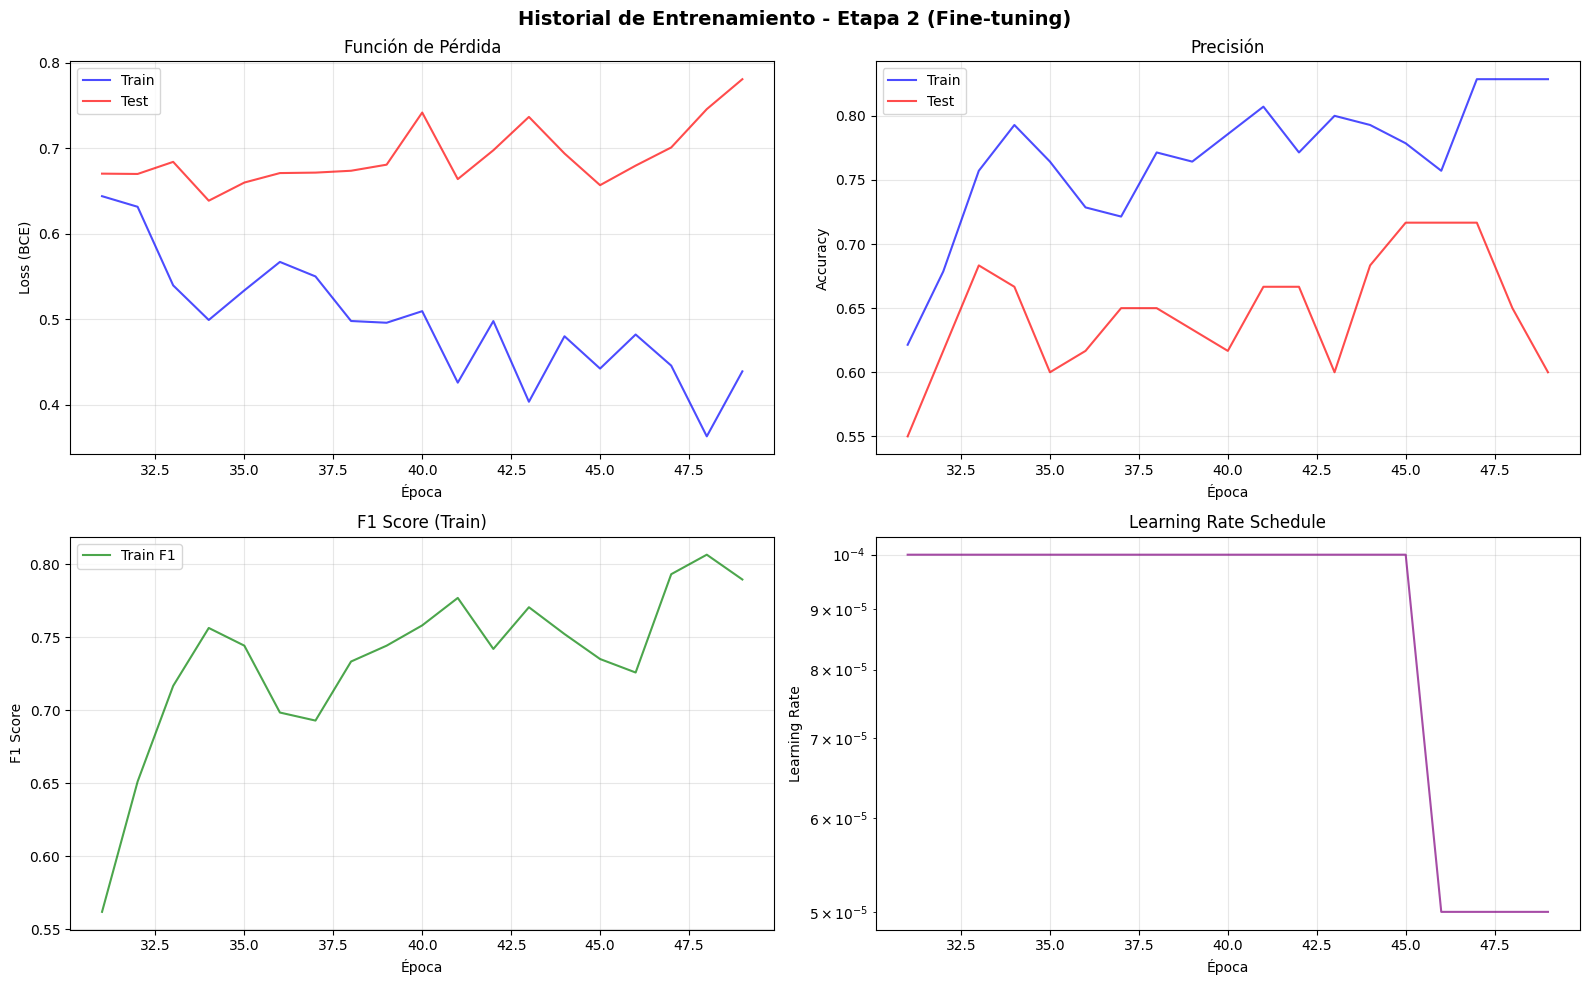

Historial guardado en results/visualizations/training_history.png


In [ ]:
# Construir historial combinado desde los datos que tenemos
# Etapa 2 (la Etapa 1 no se guardó en variable porque la función falló)
epochs = history_stage2['epoch']
train_losses = [m['loss'] for m in history_stage2['train']]
test_losses = [m['loss'] for m in history_stage2['test']]
train_accs = [m['accuracy'] for m in history_stage2['train']]
test_accs = [m['accuracy'] for m in history_stage2['test']]
train_f1s = [m['f1'] for m in history_stage2['train']]
lrs = history_stage2['lr']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Historial de Entrenamiento - Etapa 2 (Fine-tuning)', fontsize=14, fontweight='bold')

axes[0, 0].plot(epochs, train_losses, 'b-', label='Train', alpha=0.7)
axes[0, 0].plot(epochs, test_losses, 'r-', label='Test', alpha=0.7)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss (BCE)')
axes[0, 0].set_title('Función de Pérdida')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, train_accs, 'b-', label='Train', alpha=0.7)
axes[0, 1].plot(epochs, test_accs, 'r-', label='Test', alpha=0.7)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Precisión')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, train_f1s, 'g-', label='Train F1', alpha=0.7)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score (Train)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, lrs, 'purple', alpha=0.7)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/visualizations/training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Historial guardado en results/visualizations/training_history.png')

## 6. Evaluación del Mejor Modelo

In [ ]:
# Cargar y evaluar el mejor modelo
best_path = os.path.join(CHECKPOINT_DIR, 'best_model_stage2.pth')
if not os.path.exists(best_path):
    best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

checkpoint = torch.load(best_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

print(f'Mejor modelo cargado (época {checkpoint["epoch"]}, etapa {checkpoint["stage"]})')
print(f'Test loss: {checkpoint["test_loss"]:.4f}')
print(f'\nMétricas:')
for k, v in checkpoint['metrics'].items():
    print(f'  {k}: {v:.4f}')

Mejor modelo cargado (época 34, etapa 2)
Test loss: 0.6386

Métricas:
  accuracy: 0.6667
  precision: 0.6500
  recall: 0.8125
  f1: 0.7222
  auc: 0.6708
  loss: 0.6386


In [ ]:
import pandas as pd

history_df = pd.DataFrame({
    'epoch': history_stage2['epoch'],
    'stage': [2] * len(history_stage2['epoch']),
    'lr': history_stage2['lr'],
    'train_loss': [m['loss'] for m in history_stage2['train']],
    'train_accuracy': [m['accuracy'] for m in history_stage2['train']],
    'train_f1': [m['f1'] for m in history_stage2['train']],
    'test_loss': [m['loss'] for m in history_stage2['test']],
    'test_accuracy': [m['accuracy'] for m in history_stage2['test']],
    'test_f1': [m.get('f1', 0) for m in history_stage2['test']],
})

history_csv = os.path.join(PROJECT_ROOT, 'results/metrics/training_history.csv')
history_df.to_csv(history_csv, index=False)
print(f'Historial guardado en: {history_csv}')
print(f'\nÚltimas 5 épocas:')
print(history_df.tail())

Historial guardado en: /content/drive/MyDrive/cognitive-depth-model/results/metrics/training_history.csv

Últimas 5 épocas:
    epoch  stage       lr  train_loss  train_accuracy  train_f1  test_loss  \
14     45      2  0.00010    0.442236        0.778571  0.735043   0.656774   
15     46      2  0.00005    0.482077        0.757143  0.725806   0.679660   
16     47      2  0.00005    0.445687        0.828571  0.793103   0.700897   
17     48      2  0.00005    0.362926        0.828571  0.806452   0.745740   
18     49      2  0.00005    0.438980        0.828571  0.789474   0.780766   

    test_accuracy   test_f1  
14       0.716667  0.760563  
15       0.716667  0.746269  
16       0.716667  0.746269  
17       0.650000  0.676923  
18       0.600000  0.625000  


In [1]:
print('=' * 60)
print('NOTEBOOK 05 COMPLETADO')
print('=' * 60)
print()
print('Entrenamiento realizado:')
print('  Etapa 1: 30 épocas (NGL + V1 congelados)')
print('  Etapa 2: fine-tuning completo con early stopping')
print()
print('Archivos generados:')
print('  checkpoints/best_model.pth')
print('  checkpoints/best_model_stage2.pth')
print('  checkpoints/model_final.pth')
print('  results/metrics/training_history.csv')
print('  results/visualizations/training_history.png')
print()
print('Siguiente: Notebook 05b - Reentrenamiento con KITTI + Ilusiones')

NOTEBOOK 05 COMPLETADO

Entrenamiento realizado:
  Etapa 1: 30 épocas (NGL + V1 congelados)
  Etapa 2: fine-tuning completo con early stopping

Archivos generados:
  checkpoints/best_model.pth
  checkpoints/best_model_stage2.pth
  checkpoints/model_final.pth
  results/metrics/training_history.csv
  results/visualizations/training_history.png

Siguiente: Notebook 05b - Reentrenamiento con KITTI + Ilusiones
